### CA4 @ EPS Course
#### Instructors: Dr. Bahrak, Dr. Vahabie
##### TAs: Shahab Sherafat, Aidin Kazemi, Parham Heidarian
---

*Full Name:* Mohammad Hossein Kabiri

*SID:* 810103496

---

<span style="color: #177cff ; font-size: 40px;">Question 1: Shahab’s Random Thoughts</span>

![Q1.png](attachment:Q1.png)

<span style="color: gold; font-size: 30px;">Part 0: The Story</span>

Shahab, who was a passenger aboard the Titanic ship, met the one there — but lost her when the ship sank. Miraculously, he survived, keeping that pure feeling alive inside his sensitive heart. Now, finding her again is his only motivation to stay alive.

As a math geek, Shahab believes data can reveal everything — even love. He has gathered the real statistics of all Titanic passengers and wants to analyze them to find clues about her. But there were too many passengers, and he has no intuition about the data.

In [8]:
install.packages("plotly")
library(plotly)
library(viridisLite)

df <- read.csv("data.csv", header = TRUE)
c1 <- "Age"; c2 <- "Fare"; c3 <- "ReactionTime"

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



<span style="color: gold; font-size: 30px;">Part 1: Visualizing and Analyzing The Data</span>

First help Shahab visualize the dataset. Plot the distributions of the passengers’ features and explain the hidden patterns that might guide him toward finding her.

No new code needed.

In [9]:
df_plot <- df[complete.cases(df[, c(c1, c2, c3)]), ]

p <- plot_ly(
  df_plot,
  x = ~.data[[c1]],
  y = ~.data[[c2]],
  z = ~.data[[c3]],
  type = "scatter3d",
  mode = "markers",
  color = ~.data[[c3]],
  colors = viridis(256),
  marker = list(size = 4, opacity = 0.8)
) %>%
  layout(
    title = "3D Scatter",
    scene = list(
      xaxis = list(title = c1),
      yaxis = list(title = c2),
      zaxis = list(title = c3)
    )
  )

p


Output hidden; open in https://colab.research.google.com to view.

Briefly explain how the data is distributed on each feature. What probability distribution do you guess each feature has?


<span style="color: gold; font-size: 30px;">Part 2: Marginalizing and Exploring Marginal Distributions </span>

Unfortunately the joint distribution of the data can't inform him about who she was. He gets fraustrated and blames himself for some months. But unexpectedly he comes up with the idea of marginalizing the data. This way he can analyze each feature independently and find her easier!

Help him to implement the marginalize() function. You should only complete the signed parts and there is no limitation on the number of code lines.

In [10]:
marginalize <- function(x, k = 20, col_name) {
  # x: data.frame
  # k: number of bins
  # col_name: name of the column (string) whose marginal you want

  # 1) Separating the attribute values
  values <- x[[col_name]]
  values <- values[!is.na(values)]
  n <- length(values)

  # 2) Creating the breakpoints list (hint: use seq() function)
  br <- seq(min(values), max(values), length.out = k + 1)

  # 3) Counting the number of values inside each interval
  counts <- hist(values, breaks = br, plot = FALSE)$counts

  # 4) Calculating probabilities of bins
  probs <- counts / n

  # 5) Output
  mids  <- (br[-length(br)] + br[-1]) / 2
  out <- data.frame(
    mid       = mids,
    prob      = probs
  )
  return(out)
}


A bar plot (or bar chart) is a diagram that represents data using rectangular bars. The height (or length) of each bar shows the frequency or probability of values within specific categories or intervals.

In this context, each bar will represent how many passengers fall within a certain range of values — how many people paid a specific range of fares, how many were in each age group, or how their reaction times to the accident differed.

Now that Shahab has learned how to marginalize the data, he wants to visualize each feature using a bar plot. This way he can investigate the data better. Analyze the diagrams. No new code needed.

In [14]:
m1 <- marginalize(df, k = 20, col_name = c1)
m2 <- marginalize(df, k = 20, col_name = c2)
m3 <- marginalize(df, k = 20, col_name = c3)

png("pmf_Age.png", 900, 600)
barplot(m1$prob, names.arg = round(m1$mid, 2), las = 2, cex.names = 0.6,
                                     main = paste("Binned marginal of", c1), xlab = "Bin midpoints", ylab = "Probability"); dev.off()
png("pmf_Fare.png", 900, 600)
barplot(m2$prob, names.arg = round(m2$mid, 2), las = 2, cex.names = 0.6,
                                     main = paste("Binned marginal of", c2), xlab = "Bin midpoints", ylab = "Probability"); dev.off()
png("pmf_ReactionTime.png", 900, 600)
barplot(m3$prob, names.arg = round(m3$mid, 2), las = 2, cex.names = 0.6,
                                     main = paste("Binned marginal of", c3), xlab = "Bin midpoints", ylab = "Probability"); dev.off()

agg_record_699834203 
                   2

agg_record_699834203 
                   2

agg_record_699834203 
                   2

Shahab suddenly realizes that instead of marginalizing the data and drawing bar plots, he could have simply plotted histograms — visualizing the continuous beauty of each feature. The thought of how much of his life was wasted without her makes him frustrated once again.

A histogram shows how numeric data are distributed across intervals (bins), revealing patterns like skewness or spread.
Unlike a bar plot, which is for categorical data, histogram bars touch because values are continuous — making it the right choice here. Use the code below and briefly compare the barplots and histograms you plotted. No new code needed.

In [15]:
# Density Histogram
png("hist_Age.png", 900, 600)
br <- seq(min(df[[c1]], na.rm = TRUE), max(df[[c1]], na.rm = TRUE), length.out = 21)
hist(df[[c1]], main = "Histogram of Age", xlab = "Age", breaks = br, freq = FALSE); dev.off()

png("hist_Fare.png", 900, 600)
br <- seq(min(df[[c2]], na.rm = TRUE), max(df[[c2]], na.rm = TRUE), length.out = 21)
hist(df[[c2]], main = "Histogram of Fare", xlab = "Fare", breaks = br, freq = FALSE); dev.off()

png("hist_ReactionTime.png", 900, 600)
br <- seq(min(df[[c3]], na.rm = TRUE), max(df[[c3]], na.rm = TRUE), length.out = 21)
hist(df[[c3]], main = "Histogram of ReactionTime", xlab = "ReactionTime", breaks = br, freq = FALSE); dev.off()

agg_record_1990683099 
                    2

agg_record_1990683099 
                    2

agg_record_1990683099 
                    2

<span style="color: gold; font-size: 30px;">Part 3: Recognizing Probability Distributions </span>

Now that Shahab has visualized the marginal distributions, he wants to go one step further and check which theoretical distribution best fits each feature. To do this, he will use a Quantile–Quantile Plot (QQ-plot) — a graphical tool for comparing the distribution of a dataset with a theoretical one.

In a QQ-plot, each point represents a pair of quantiles: one from the observed data, and one from the theoretical distribution. If the data truly follows the theoretical distribution, the points will approximately lie on a straight line. Systematic deviations from that line indicate that the data does not match that distribution family — for example, curved patterns or heavy tails show mismatches.

Now, Shahab will compare each of the three selected features (Age, Fare, ReactionTime) against three candidate distributions:

1. Normal distribution

2. [Log-normal distribution](https://en.wikipedia.org/wiki/Log-normal_distribution)

3. Exponential distribution

The code to generate these QQ-plots has already been written — just understand and run it.

After generating the plots, describe which distribution seems to fit each feature best, and explain why based on the shape of the QQ-plot (whether the points align closely with the fit line or deviate systematically).

In [16]:
#Don't touch, just run.

qqexp <- function(v, main = "QQ vs Exponential") {
  v <- v[is.finite(v) & !is.na(v) & v > 0]
  n <- length(v)
  if (n < 5) {
    warning("Not enough positive observations for exponential QQ plot.")
    return(invisible(NULL))
  }
  v <- sort(v)
  rate_hat <- 1 / mean(v)
  th <- qexp(ppoints(n), rate = rate_hat)

  qqplot(th, v,
         main = sprintf("%s", main),
         xlab = "Theoretical quantiles (Exp)",
         ylab = "Sample quantiles",
         pch = 19, col = "blue")
  abline(0, 1, col = "red", lwd = 2)
}

In [17]:
# Age
png("qq_Age.png", 1500, 500)
par(mfrow = c(1, 3))
# Normal
qqnorm(df[[c1]], main = "QQ plot Age vs Normal", col = "blue")
qqline(df[[c1]], col = "red")
# Log-Normal
qqnorm(log(df[[c1]][df[[c1]] > 0]), main = "QQ plot Age vs Log-Normal", col = "blue")
qqline(log(df[[c1]][df[[c1]] > 0]), col = "red")
# Exponential
qqexp(df[[c1]], main = paste("QQ:", c1, "vs Exponential"))
dev.off()


# Fare
png("qq_Fare.png", 1500, 500)
par(mfrow = c(1, 3))
# Normal
qqnorm(df[[c2]], main = "QQ plot Fare vs Normal", col = "blue")
qqline(df[[c2]], col = "red")
# Log-Normal
qqnorm(log(df[[c2]][df[[c2]] > 0]), main = "QQ plot Fare vs Log-Normal", col = "blue")
qqline(log(df[[c2]][df[[c2]] > 0]), col = "red")
# Exponential
qqexp(df[[c2]], main = paste("QQ:", c2, "vs Exponential"))
dev.off()


# ReactionTime
png("qq_ReactionTime.png", 1500, 500)
par(mfrow = c(1, 3))
# Normal
qqnorm(df[[c3]], main = "QQ plot ReactionTime vs Normal", col = "blue")
qqline(df[[c3]], col = "red")
# Log-Normal
qqnorm(log(df[[c3]][df[[c3]] > 0]), main = "QQ plot ReactionTime vs Log-Normal", col = "blue")
qqline(log(df[[c3]][df[[c3]] > 0]), col = "red")
# Exponential
qqexp(df[[c3]], main = paste("QQ:", c3, "vs Exponential"))
dev.off()

agg_record_680910122 
                   2

agg_record_680910122 
                   2

agg_record_680910122 
                   2

<span style="color: gold; font-size: 30px;">Part 4: Narrowing The Search Domain By Acquired Distributions</span>

Now that Shahab has identified the most likely distributions for each feature,
he wants to estimate how many passengers might match his memory.

Based on the chosen distributions:

1. Estimate the parameters of each (e.g., mean & variance for Normal, λ for Exponential, etc.).

2. Compute the theoretical probability of each variable falling within Shahab’s recalled ranges:

    Age ∈ [19, 25]

    Fare ∈ [30, 100]

    Reaction Time ∈ [0.05, 0.8]

3. Assuming independence, multiply these probabilities to get the joint probability.

4. Finally, multiply that probability by the total number of valid passengers(1309) to estimate
how many people Shahab’s search might realistically include.

In [18]:
age_lo <- 19; age_hi <- 25
fare_lo <- 30; fare_hi <- 100
rt_lo   <- 0.05; rt_hi   <- 0.8
N <- 1309

In [19]:
# 1) Estimate parameters from data
mu_age       <- mean(df$Age, na.rm = TRUE)
sd_age       <- sd(df$Age, na.rm = TRUE)
meanlog_fare <- mean(log(df$Fare[df$Fare > 0]), na.rm = TRUE)
sdlog_fare   <- sd(log(df$Fare[df$Fare > 0]), na.rm = TRUE)
rate_rt      <- 1 / mean(df$ReactionTime, na.rm = TRUE)

# 2) Compute probabilities for each range
p_age  <- pnorm(age_hi, mean = mu_age, sd = sd_age) - pnorm(age_lo, mean = mu_age, sd = sd_age)
p_fare <- plnorm(fare_hi, meanlog = meanlog_fare, sdlog = sdlog_fare) - plnorm(fare_lo, meanlog = meanlog_fare, sdlog = sdlog_fare)
p_rt   <- pexp(rt_hi, rate = rate_rt) - pexp(rt_lo, rate = rate_rt)

# 3) Joint probability assuming independence
p_joint <- p_age * p_fare * p_rt

# 4) Expected count among 1309 passengers
expected_count <- N * p_joint

cat(sprintf("P(Age)=%.4f, P(Fare)=%.4f, P(ReactionTime)=%.4f\nJoint P=%.6f → Expected count ≈ %.2f people\n",
            p_age, p_fare, p_rt, p_joint, expected_count))

P(Age)=0.1453, P(Fare)=0.2732, P(ReactionTime)=0.4999
Joint P=0.019844 → Expected count ≈ 25.98 people


Now count the real number of passengers satisfying those conditions. No new code needed. Just understand and run it.

In [20]:
cond_age  <- !is.na(df[[c1]]) & df[[c1]] >= age_lo & df[[c1]] <= age_hi
cond_fare <- !is.na(df[[c2]]) & df[[c2]] >= fare_lo & df[[c2]] <= fare_hi
cond_rt   <- !is.na(df[[c3]]) & df[[c3]] >= rt_lo & df[[c3]] <= rt_hi

cond_all  <- cond_age & cond_fare & cond_rt
count_all <- sum(cond_all)

pct_all_total <- count_all / N

cat("Count (all conditions met):", count_all, "\n")
cat("Percent among ALL rows:", round(100*pct_all_total, 2), "%\n")

Count (all conditions met): 26 
Percent among ALL rows: 1.99 %


Do the theoretical estimated and empirical counts match? Did you provide a good estimation for Shahab?

<span style="color: gold; font-size: 30px;">Part 5: Limited Number of Checks</span>

Because he's unbelievably lazy, Shahab can only check a limited number of people; only less or equal to 19 people. From the earlier analysis he has an estimate p_joint for the probability that a randomly chosen person in the passengers list matches the clue (the features he is looking for).

To solve this problem, he consulted with Bernouli himself. Bernouli advised him to consider each check as a Bernouli(p_joint) random variable. This means the total number of eligible ones, X, follows a Binomial distribution: X∼Binomial(N, p_joint)

Bernouli gave Shahab the code to do this himself, just run and analyze it.

P(X <= 19) = 0.095 


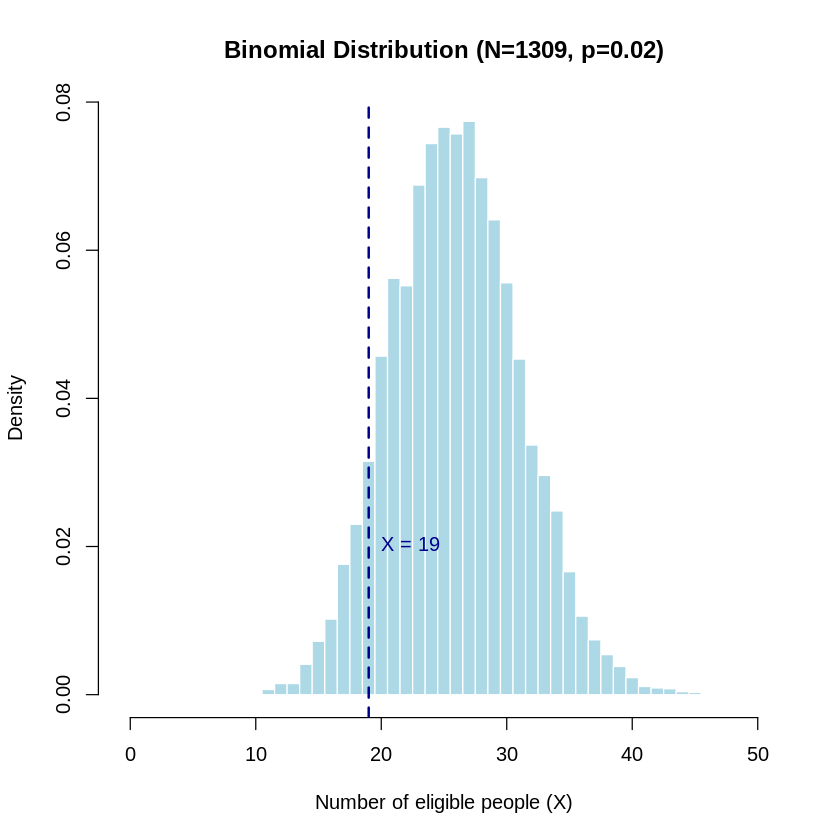

In [21]:
num_eligible <- 19

set.seed(42)
X <- rbinom(10000, size = N, prob = p_joint)

prob_binom <- pbinom(num_eligible, size = N, prob = p_joint)
cat("P(X <= 19) =", round(prob_binom, 3), "\n")

hist(X,
     breaks = seq(-0.5, 50.5, 1),
     probability = TRUE,
     col = "lightblue",
     border = "white",
     main = sprintf("Binomial Distribution (N=%d, p=%.2f)", N, p_joint),
     xlab = "Number of eligible people (X)")

abline(v = 19, col = "darkblue", lty = 2, lwd = 2)
text(19, 0.02, labels = "X = 19", pos = 4, col = "darkblue")


When Gauss saw that Shahab had followed Bernoulli’s advice, he got jealous.
He appeared beside Shahab and said, “Why use the exact Binomial when you can approximate it with my Normal distribution?”
Gauss showed him the bell curve, explained the mean and variance and asked you to calculate P(X <= 19) using Normal approximation.

First let's plot the approximation besides the origin Binomial:

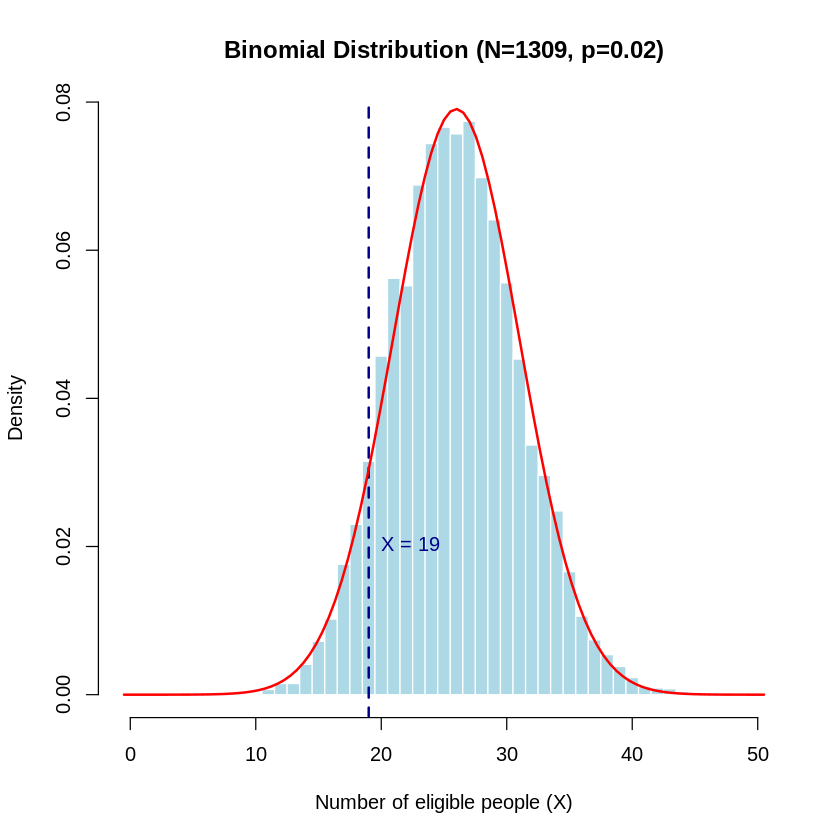

In [22]:
hist(X,
     breaks = seq(-0.5, 50.5, 1),
     probability = TRUE,
     col = "lightblue",
     border = "white",
     main = sprintf("Binomial Distribution (N=%d, p=%.2f)", N, p_joint),
     xlab = "Number of eligible people (X)")

abline(v = 19, col = "darkblue", lty = 2, lwd = 2)
text(19, 0.02, labels = "X = 19", pos = 4, col = "darkblue")


mu <-  N * p_joint
sigma <- sqrt(N * p_joint * (1 - p_joint))
curve(dnorm(x, mean = mu, sd = sigma),
      add = TRUE, col = "red", lwd = 2)

Now let's calculate the probability anc compare:

In [23]:
prob_norm <- pnorm(num_eligible, mean = mu, sd = sigma)

cat("Exact Binomial   P(X <= 19) =", round(prob_binom, 3), "\n")
cat("Normal approx    P(X <= 19) =", round(prob_norm, 3), "\n")

Exact Binomial   P(X <= 19) = 0.095 
Normal approx    P(X <= 19) = 0.083 


But unfortunately the approximation-based calculated probability doesn't fit the exact binomial probability, Gauss's heart has been broken!

What is the matter? What can we do to make Gauss happy? Implement it.

In [24]:
prob_norm_fixed <- pnorm(19 + 0.5, mean = mu, sd = sigma)

cat("Exact Binomial   P(X <= 19) =", round(prob_binom, 3), "\n")
cat("Normal approx    P(X <= 19) =", round(prob_norm_fixed, 3), "\n")

Exact Binomial   P(X <= 19) = 0.095 
Normal approx    P(X <= 19) = 0.1 


<span style="color: #177cff ; font-size: 40px;">Question 2: Aidin Not Replying Parham</span>

![Q2.png](attachment:Q2.png)

<span style="color: gold; font-size: 30px;">Part 0: The Story</span>

Aidin has a successful startup, and because of his tight schedule, he doesn’t answer messages quickly. Lately, Parham — a math genius who’s been searching for a job — has become interested in joining Aidin’s company and is always trying to prove himself to him.

Whenever Parham messages Aidin on Telegram, he knows he’ll have to wait for a reply and the waiting time seems to follow an Exponential distribution. Since Parham is eager to show he’s always available, he replies instantly the moment Aidin sends anything back. This habit has shaped his phone-usage pattern: Parham only touches his phone when Aidin messages him.

Shahab, who decided to become a therapist after he didn't succeed, wants to help Parham by analyzing his mobile usage pattern. He guesses that the number of times Parham touches his mobile in an hour follows an Exponential distribution; but he can't prove it. Assist him to figure out if he's right.

<span style="color: gold; font-size: 30px;">Part 1: Simulation</span>

In this part you have to implement the count_from_exponential() function. The function count_from_exponential() simulates how many events happen within each fixed time interval when the time between consecutive events follows an exponential distribution.

T → the length of each time window (e.g. 1 hour)

lambda → the event rate (average number of events per unit time)

num_of_simulations → how many intervals to simulate

Inside the function, it repeatedly generates exponential waiting times (using rexp()), adds them up, and counts how many events occur before crossing the time limit T.
This process is repeated for all intervals, producing a vector of event counts.

<span style="color:rgb(255, 23, 23) ; font-size: 20px;">NOTE:</span> Consider that the sampled t can be larger than the unit time; so handle the validity of values inside counts array. Be careful!

In [27]:
set.seed(123)

lambda <- 4        # The rate of events in each time unit
T_horizon <- 1.0   # Time unit
R <- 1000000       # Number of simulations

In [28]:
count_from_exponential <- function(T, lambda, num_of_simulations){
    counts_variables <- integer(num_of_simulations)
    counter <- 1

    while(counter <= num_of_simulations){
        t <- 0          # cumulative time within the interval
        count <- 0      # number of events in this interval

        while(TRUE){
            t_next <- rexp(1, rate = lambda)  # sample next waiting time
            if (t + t_next > T) break         # stop if we exceed the interval
            t <- t + t_next
            count <- count + 1
        }

        counts_variables[counter] <- count
        counter <- counter + 1
    }

    return(counts_variables)
}


Now using the simulation function you've implemented (I hope!), let's generate the counts array and compare it with a Poisson distributed data.

First let's compare the basic statistics:

In [29]:
counts <- count_from_exponential(T_horizon, lambda, R)

pois_mean <- lambda * T_horizon

cat("Empirical mean:", mean(counts), "\n")
cat("Empirical var :", var(counts),  "\n")
cat("Theoretical (Poisson) mean=var:", pois_mean, "\n")

Empirical mean: 3.999189 
Empirical var : 4.007648 
Theoretical (Poisson) mean=var: 4 


Do they match? (If the answer is negative you're gonna have to review your function :) ) Does it fit your intuition?

Now let's generate and compare:

In [30]:
poisson_samples <- rpois(R, pois_mean)

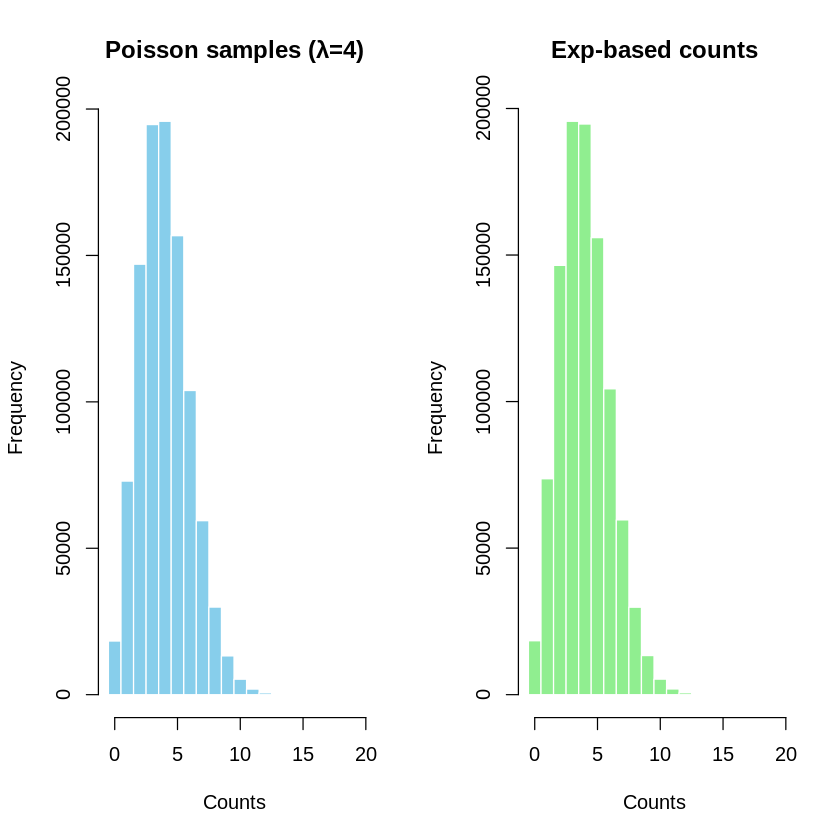

In [31]:
common_max <- max(poisson_samples, counts, na.rm = TRUE)
br <- seq(-0.5, common_max + 0.5, by = 1)

par(mfrow = c(1, 2))

hist(poisson_samples, breaks = br, freq = TRUE,
     col = "skyblue", main = "Poisson samples (λ=4)",
     xlab = "Counts", border = "white", xlim = c(-0.5, common_max + 0.5))

hist(counts, breaks = br, freq = TRUE,
     col = "lightgreen", main = "Exp-based counts",
     xlab = "Counts", border = "white", xlim = c(-0.5, common_max + 0.5))

par(mfrow = c(1, 1))

Now what? Do they look similar? Try playing with the number of simulations and comparing again.

Now let's see the QQPlot (remember from Problem 1) for these two distributions:

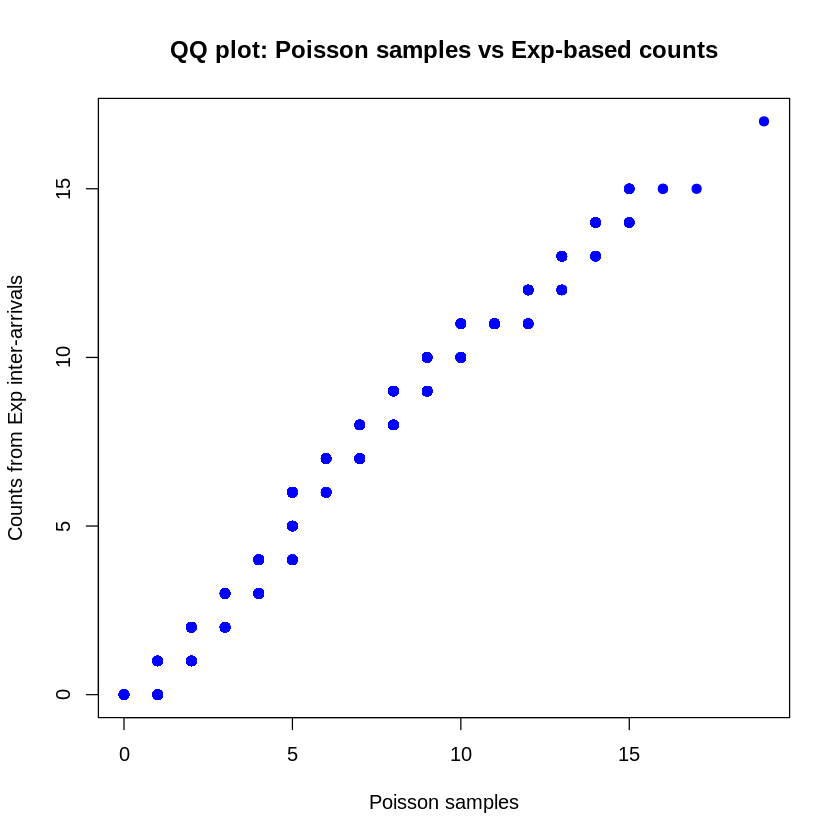

In [32]:
par(mfrow=c(1,1))

qqplot(poisson_samples, counts,
       main = "QQ plot: Poisson samples vs Exp-based counts",
       xlab = "Poisson samples",
       ylab = "Counts from Exp inter-arrivals",
       col = "blue", pch = 19)

As you can see, the quantiles match on a straight line.

<span style="color: gold; font-size: 30px;">Part 2: Memorylessness</span>

Therapy failed! Parham has messaged Aidin again, and as we know the time it takes for Aidin to see and respond follows an Exponential distribution. Parham has already waited for 12 hours and now believes that the probability of Aidin replying within the next hour must be higher than it was before—after all, he’s waited so long!

Let’s prove to him that he’s wrong.

In [33]:
set.seed(42)

lambda <- 0.25   # rate (per hour) -- mean = 1/lambda hours
s <- 10          # Spent hours with no answers
t <- 2           # Future hours
N <- 1000000     # Number of samples

In [34]:
x <- rexp(N, rate = lambda)

First calculate each probability, considering the conditional probability law:

In [35]:
# P(X > t):
P_gt_t_emp        <- mean(x > t)             # P(X > t)
P_gt_s_emp        <- mean(x > s)             # P(X > s)
P_gt_s_plus_t_emp <- mean(x > s + t)         # P(X > s + t)
P_cond_emp        <- P_gt_s_plus_t_emp / P_gt_s_emp  # P(X > s+t | X > s)


Now let's compare the probabilities theoretically:

In [36]:
cat(sprintf("Parameters: lambda=%.4g, s=%.3g, t=%.3g, N=%d\n\n",
            lambda, s, t, N))

cat(sprintf("Empirical P(X > t)             = %.6f\n", P_gt_t_emp))
cat(sprintf("Empirical P(X > s)             = %.6f\n", P_gt_s_emp))
cat(sprintf("Empirical P(X > s + t)         = %.6f\n", P_gt_s_plus_t_emp))
cat(sprintf("Empirical P(X > s+t | X > s)   = %.6f\n\n", P_cond_emp))

cat(sprintf("Difference |P(X>t) - P(X>s+t|X>s)| = %.8f\n",
            abs(P_gt_t_emp - P_cond_emp)))

Parameters: lambda=0.25, s=10, t=2, N=1000000

Empirical P(X > t)             = 0.606893
Empirical P(X > s)             = 0.082047
Empirical P(X > s + t)         = 0.049679
Empirical P(X > s+t | X > s)   = 0.605494

Difference |P(X>t) - P(X>s+t|X>s)| = 0.00139859


What conclusion do you gain?